# Projeto: 📊 Análise de Performance de Vendas (SQL & Python)
**Analista Responsável:** Douglas de Jesus Vittori

## Perguntas de Negócio (Roadmap da Análise)
O projeto foi estruturado para responder às seguintes questões estratégicas:

1. **Integridade Financeira:** Qual o faturamento total real da empresa?
2. **Performance Regional:** Quais as 5 cidades que apresentam o maior faturamento acumulado?
3. **Mix de Produtos:** Quais são os 10 produtos que mais geram receita?
4. **Eficiência de Venda:** Qual o valor médio investido por transação (**Ticket Médio**)?
5. **Fidelização (CRM):** Quem são os clientes **VIP** (gasto > R$ 500,00)?
6. **Inteligência Logística:** Qual o produto "Best-Seller" individual de cada cidade?

In [1]:
# Imports 
import duckdb
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Versões dos pacotes usados neste jupyter notebook
%reload_ext watermark
%watermark -a "Douglas Vittori"

Author: Douglas Vittori



In [3]:
# Cria uma conexão em memória (o banco vive apenas enquanto o script roda)
con = duckdb.connect(database=':memory:')

In [4]:
# Registra os CSVs como tabelas no banco de dados
con.execute("CREATE TABLE pedidos AS SELECT * FROM 'orders.csv'")
con.execute("CREATE TABLE clientes AS SELECT * FROM 'customers.csv'")
con.execute("CREATE TABLE produtos AS SELECT * FROM 'products.csv'")

In [5]:
# Visualizando as 5 primeiras linhas de cada tabela com query SQL
print("Tabela Pedidos\n")
resultado_pedidos = con.execute("""
SELECT * FROM pedidos
LIMIT 5
""").df()

display(resultado_pedidos)
print("----" * 18)

print("Tabela Clientes\n")
resultado_clientes = con.execute("""
SELECT * FROM clientes
LIMIT 5
""").df()

display(resultado_clientes)
print("----" * 18)

print("Tabela Produtos\n")
resultado_produtos = con.execute("""
SELECT * FROM produtos
LIMIT 5
""").df()

display(resultado_produtos)

Tabela Pedidos



,order_id,customer_id,product_id,order_date,quantity,payment_method
0,O00001,C0692,P006,2023-01-29,4,Card
1,O00002,C1072,P059,2023-04-19,5,Card
2,O00003,C1187,P030,2024-01-15,1,Card
3,O00004,C0290,P063,2024-01-12,1,Cash
4,O00005,C0094,P032,2024-04-09,2,Card


------------------------------------------------------------------------
Tabela Clientes



,customer_id,gender,age,city,signup_date,loyalty_member
0,C0001,Male,19,Liverpool,2023-10-17,True
1,C0002,Male,65,Manchester,2022-08-17,True
2,C0003,Female,20,London,2023-08-28,True
3,C0004,Male,50,London,2022-08-12,True
4,C0005,Female,32,Nottingham,2023-10-28,False


------------------------------------------------------------------------
Tabela Produtos



,product_id,product_name,category,price
0,P001,Blender 1,Beauty,272.76
1,P002,Perfume 2,Home,132.09
2,P003,Water Bottle 3,Home,58.58
3,P004,Smart Watch 4,Home,220.82
4,P005,Perfume 5,Home,27.81


### 📊 1. Visão Geral: Faturamento Total
Antes de mergulhar nos detalhes, precisamos entender o tamanho do volume financeiro transacionado na base de dados.

> **Pergunta de Negócio:** Qual o faturamento total acumulado em todos os pedidos?

In [6]:
# SQL
faturamento_total = con.execute("""
SELECT 
    SUM(pr.price * p.quantity) AS faturamento_total
FROM 
    pedidos p
JOIN produtos pr ON pr.product_id = p.product_id
""").df()

In [7]:
# Extrai o valor numérico e formata para exibir como moeda
valor = faturamento_total['faturamento_total'][0]
print(f"O faturamento total da empresa foi de: R$ {valor:,.2f}")

O faturamento total da empresa foi de: R$ 1,644,817.71


### 👥 2. Alcance da Base: Clientes Únicos
Para entender a penetração de mercado da empresa, precisamos saber quantos consumidores reais (únicos) realizaram transações, desconsiderando repetições de compra pelo mesmo ID.

* **Pergunta de Negócio:** Quantos clientes cadastrados realizaram pelo menos uma compra?
* **Técnica SQL utilizada:** Função de agregação `COUNT` combinada com a cláusula `DISTINCT` para eliminar duplicatas de IDs.

In [8]:
# SQL
clientes_unicos = con.execute("""
    SELECT COUNT(DISTINCT customer_id) AS total_clientes
    FROM clientes
""").df()

# Usando a técnica do .iloc para não ter erro de nome:
total = clientes_unicos.iloc[0, 0]
print(f"Total de clientes únicos: {total}")

Total de clientes únicos: 1200


### 📍 3. Performance Regional: Faturamento por Cidade
Como a base de dados não fornece o valor total de cada pedido pronto, realizamos o cruzamento entre as tabelas de pedidos e produtos para calcular o faturamento real por localidade.

* **Pergunta de Negócio:** Quais são as 5 cidades que geraram o maior faturamento total?
* **Técnica SQL utilizada:** `JOIN` triplo (Pedidos + Clientes + Produtos), cálculo aritmético (`Quantidade * Preço`) e função de agregação `SUM`.

In [9]:
# SQL
top_5_cidades_que_mais_faturam = con.execute("""
SELECT 
    c.city AS Cidade,
    SUM(pr.price * p.quantity) AS Faturamento_Total
FROM 
    pedidos p 
JOIN clientes c 
    ON c.customer_id = p.customer_id
JOIN produtos pr 
    ON pr.product_id = p.product_id
GROUP BY c.city
ORDER BY Faturamento_Total DESC
LIMIT 5
""").df()

display(top_5_cidades_que_mais_faturam)


,Cidade,Faturamento_Total
0,Sheffield,233607.88
1,Birmingham,224892.95
2,Nottingham,213151.66
3,Bristol,202317.33
4,Liverpool,197613.63


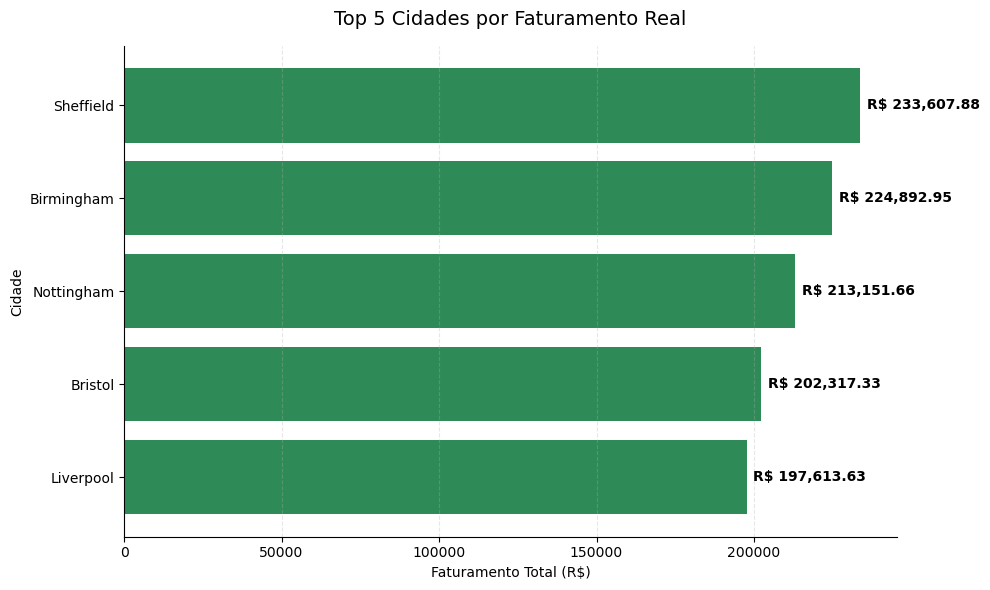

In [10]:
# Configurando o tamanho da figura
plt.figure(figsize=(10, 6))

# Criando as barras horizontais
# Usamos 'Faturamento_Total' e 'Cidade' do DataFrame faturamento_cidade_df
bars = plt.barh(top_5_cidades_que_mais_faturam['Cidade'], top_5_cidades_que_mais_faturam['Faturamento_Total'], color='seagreen')

# --- ADICIONANDO OS LABELS (VALORES) ---
for bar in bars:
    width = bar.get_width()
    # plt.text(x, y, texto, ...)
    plt.text(width + (width * 0.01), # Pequeno espaço após o fim da barra
             bar.get_y() + bar.get_height()/2, 
             f'R$ {width:,.2f}', 
             va='center', fontsize=10, fontweight='bold')
# ---------------------------------------

# Estilização Profissional
plt.title('Top 5 Cidades por Faturamento Real', fontsize=14, pad=15)
plt.xlabel('Faturamento Total (R$)')
plt.ylabel('Cidade')
plt.gca().invert_yaxis() # Maior faturamento no topo

# Removendo linhas desnecessárias para o gráfico ficar "limpo"
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### 🏆 4. Performance de Produto: Top 10 Mais Vendidos
Identificar quais produtos possuem o maior giro de estoque e qual a contribuição financeira de cada um para o faturamento total.

* **Pergunta de Negócio:** Quais são os 10 produtos com maior volume de vendas (quantidade) e qual o faturamento total gerado por cada um?
* **Técnica SQL utilizada:** `JOIN` entre as tabelas de Produtos e Pedidos, funções de agregação `SUM` para quantidade e faturamento, e agrupamento por nome de produto.

In [11]:
# SQL
top_10_produtos_mais_vendidos = con.execute("""
SELECT 
    pr.product_name AS Nome_Produto,
    SUM(p.quantity) AS Total_Vendido,
    SUM(p.quantity * pr.price) AS Faturamento_Total
FROM produtos pr 
JOIN pedidos p 
    ON pr.product_id = p.product_id
GROUP BY Nome_Produto
ORDER BY Total_Vendido DESC
LIMIT 10
""").df()
display(top_10_produtos_mais_vendidos)

,Nome_Produto,Total_Vendido,Faturamento_Total
0,Monitor 55,201.0,8329.44
1,Wireless Mouse 60,193.0,10261.81
2,Bluetooth Speaker 18,191.0,43605.30
3,Face Cream 67,178.0,18992.60
4,Water Bottle 71,178.0,10897.16
5,USB Cable 65,178.0,13439.00
6,Vacuum Cleaner 6,177.0,10448.31
7,Yoga Mat 48,177.0,37300.98
8,Jacket 23,176.0,17142.40
9,Perfume 59,175.0,41195.00


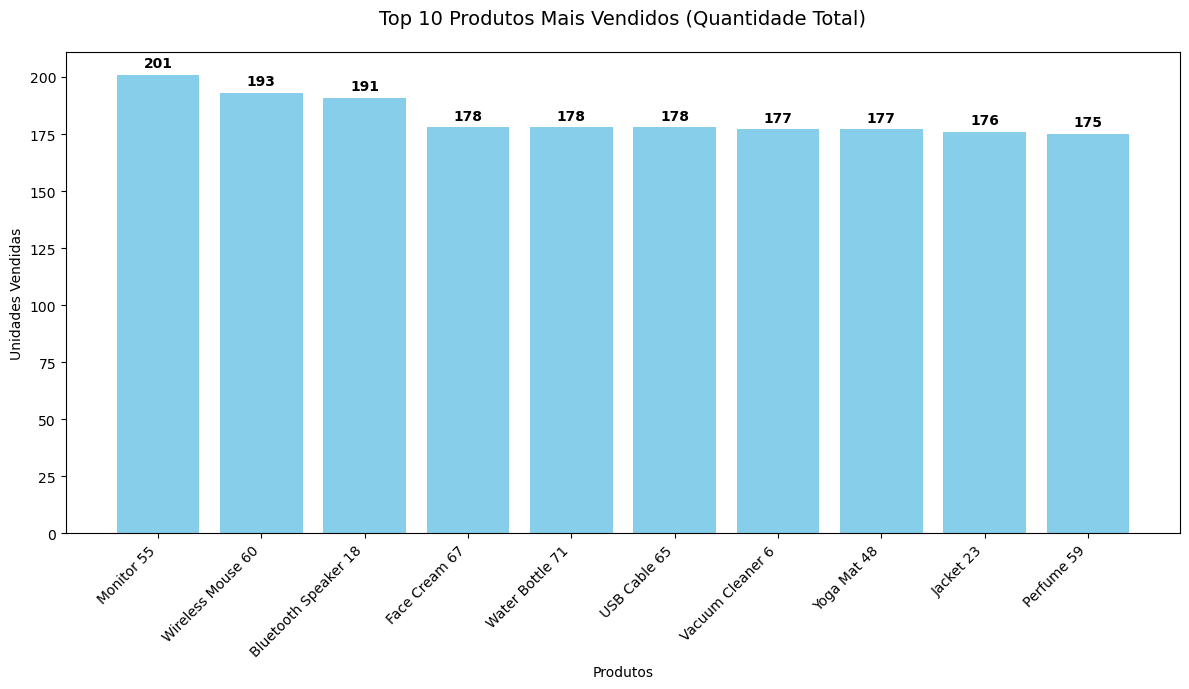

In [12]:
# Configurando o tamanho da figura
plt.figure(figsize=(12, 7))

# Criando as barras
bars = plt.bar(top_10_produtos_mais_vendidos['Nome_Produto'], top_10_produtos_mais_vendidos['Total_Vendido'], color='skyblue')

# --- ADICIONANDO OS LABELS (VALORES) ---
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, 
             f'{int(yval)}', # O valor formatado como inteiro
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Estilização
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Produtos Mais Vendidos (Quantidade Total)', fontsize=14, pad=20)
plt.ylabel('Unidades Vendidas')
plt.xlabel('Produtos')

plt.tight_layout()
plt.show()

### 💡 Insights sobre o Mix de Produtos
Ao cruzar a **Quantidade Vendida** com o **Faturamento Real**, identificamos que:

1. **Líder de Volume:** O *Monitor 55* é o item mais popular (201 unid.), porém possui o menor ticket médio da lista, funcionando como um produto de aquisição de clientes.
2. **Líderes de Receita:** Os itens *Bluetooth Speaker 18* e *Perfume 59* são os pilares financeiros da empresa, gerando mais de R$ 40 mil cada em receita.
3. **Oportunidade de Estoque:** Itens como *Yoga Mat* e *Jacket* possuem giro alto e valor elevado. Garantir que não haja ruptura de estoque (out-of-stock) para estes itens é a prioridade nº 1 da operação.

### 📍 5. Perfil de Consumo Regional: Média de Preço por Cidade
Não basta saber quanto cada cidade fatura; precisamos entender o perfil de compra de cada região. Cidades com média de preço elevada indicam um público com maior poder aquisitivo ou preferência por produtos Premium.

* **Pergunta de Negócio:** Qual a média de preço dos produtos vendidos em cada cidade?
* **Técnica SQL utilizada:** `JOIN` triplo, função de agregação `AVG` (Média) aplicada sobre o preço dos produtos vendidos.

In [13]:
# SQL
media_preco_por_cidade = con.execute("""
SELECT c.city AS Cidade,
       AVG(pr.price) AS Media_Preco_Vendido
FROM pedidos p
JOIN produtos pr ON p.product_id = pr.product_id
JOIN clientes c ON p.customer_id = c.customer_id
GROUP BY c.city
ORDER BY Media_Preco_Vendido DESC
""").df()
display(media_preco_por_cidade)
       
       

,Cidade,Media_Preco_Vendido
0,Sheffield,144.960162
1,Manchester,142.314163
2,Leeds,141.769009
3,Liverpool,138.763996
4,Bristol,138.489434
5,Nottingham,138.364508
6,Birmingham,137.292834
7,London,134.251550


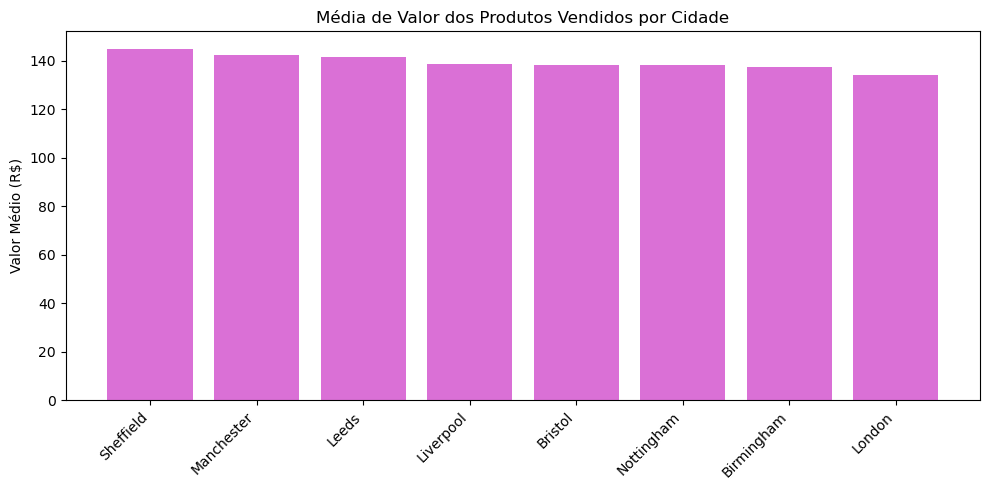

In [14]:
# Configurando o tamanho da figura
plt.figure(figsize=(10, 5))
plt.bar(media_preco_por_cidade['Cidade'], media_preco_por_cidade['Media_Preco_Vendido'], color='orchid')

plt.title('Média de Valor dos Produtos Vendidos por Cidade')
plt.ylabel('Valor Médio (R$)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### 💎 6. Identificação de Clientes VIP (Fidelidade)
Segmentar clientes por volume de gastos é essencial para estratégias de CRM. Nesta análise, filtramos apenas os clientes que superaram R$ 500,00 em compras acumuladas, focando nos 10 maiores faturamentos individuais.

* **Pergunta de Negócio:** Quem são os nossos 10 clientes com maior investimento acumulado?
* **Técnica SQL utilizada:** `JOIN` triplo, `SUM` com cálculo de faturamento real, `GROUP BY`, `HAVING` para filtro de valor e `LIMIT 10`.

In [15]:
# SQL
top_clientes_vip = con.execute("""
SELECT p.customer_id AS Cliente,
       SUM(pr.price * p.quantity) AS Total_Gasto
FROM pedidos p
JOIN produtos pr ON p.product_id = pr.product_id
GROUP BY Cliente
HAVING Total_Gasto > 500
ORDER BY Total_Gasto DESC
LIMIT 10
""").df()

display(top_clientes_vip)

,Cliente,Total_Gasto
0,C0299,5124.21
1,C0094,5078.51
2,C0588,4874.30
3,C0826,4685.22
4,C0334,4515.14
5,C0291,4508.31
6,C0765,4505.37
7,C0157,4459.55
8,C1167,4425.53
9,C0674,4356.89


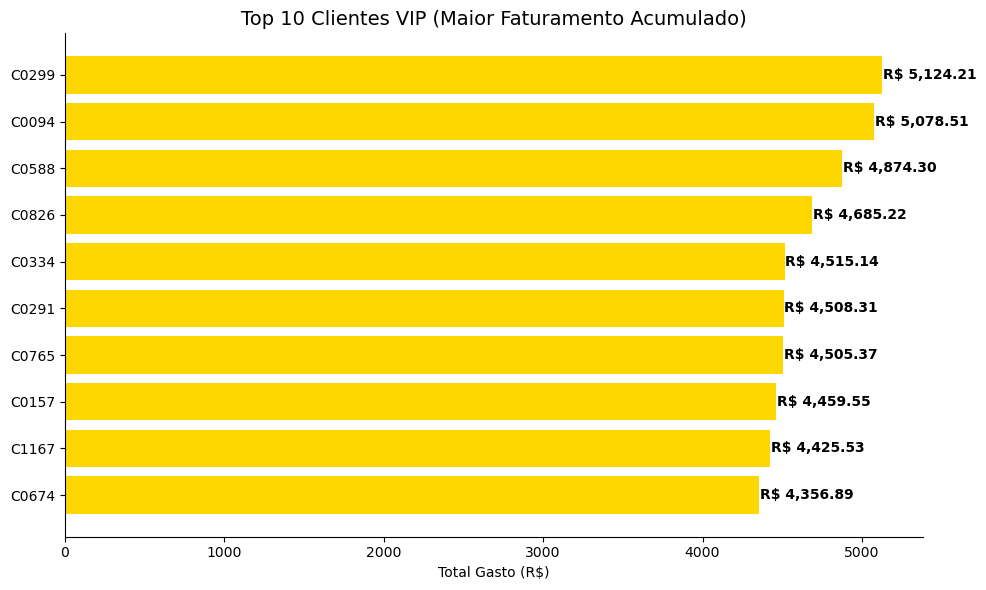

In [16]:
# Configurando o tamanho da figura
plt.figure(figsize=(10, 6))

# Criando as barras horizontais
bars = plt.barh(top_clientes_vip['Cliente'], top_clientes_vip['Total_Gasto'], color='gold')

# Adicionando os valores formatados na ponta de cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2, 
             f'R$ {width:,.2f}', 
             va='center', fontsize=10, fontweight='bold')

plt.title('Top 10 Clientes VIP (Maior Faturamento Acumulado)', fontsize=14)
plt.xlabel('Total Gasto (R$)')
plt.gca().invert_yaxis() # Inverte para o 1º lugar ficar no topo

# Removendo bordas para um design mais moderno
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**insight:** O Top 10 de clientes VIP representa uma parcela crítica do faturamento. Note que o ticket acumulado desses clientes é significativamente superior à média. Estratégias de 'Account Management' para esses perfis podem garantir que eles continuem escolhendo nossa marca em vez da concorrência.

### 🛒 7. Eficiência de Venda: Ticket Médio por Pedido
O Ticket Médio é uma métrica fundamental que indica o valor médio gasto pelos clientes em cada transação. Ele ajuda a medir a saúde financeira e a eficácia das estratégias de "upselling".

* **Pergunta de Negócio:** Qual o valor médio faturado por cada pedido realizado na plataforma?
* **Técnica SQL utilizada:** `Subquery` para consolidar o valor total de cada `order_id` (Quantidade * Preço) e, em seguida, a função `AVG` para extrair a média geral.

In [17]:
# SQL
ticket_medio_geral = con.execute("""
    SELECT AVG(valor_total_pedido) AS Ticket_Medio_Global
    FROM (
        SELECT 
            p.order_id, 
            SUM(p.quantity * pr.price) AS valor_total_pedido
        FROM pedidos p
        JOIN produtos pr ON p.product_id = pr.product_id
        GROUP BY p.order_id
    )
""").df()

# Exibindo o valor consolidado
display(ticket_medio_geral)

,Ticket_Medio_Global
0,411.204428


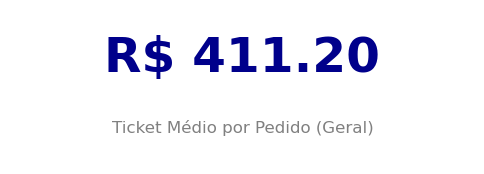

In [18]:
# Extraindo o valor numérico
valor_final = ticket_medio_geral.iloc[0, 0]

# Criando um visual de Dashboard
plt.figure(figsize=(6, 2))
plt.text(0.5, 0.6, f"R$ {valor_final:,.2f}", fontsize=35, fontweight='bold', ha='center', color='darkblue')
plt.text(0.5, 0.2, "Ticket Médio por Pedido (Geral)", fontsize=12, ha='center', color='gray')
plt.axis('off')
plt.show()

### 🏆 8. Liderança Regional: Produto Mais Vendido por Cidade
Esta análise identifica a preferência de consumo local, permitindo que a empresa personalize estoques e campanhas de marketing de acordo com a demanda específica de cada região.

* **Pergunta de Negócio:** Qual é o produto campeão de vendas (em quantidade) para cada cidade?
* **Técnica SQL utilizada:** `CTE` (Common Table Expression) para organizar a consulta, `JOIN` triplo e a Window Function `RANK()` com a cláusula `PARTITION BY` para criar um ranking independente para cada cidade.

In [19]:
# SQL
produto_por_cidade = con.execute("""
WITH VendasPorCidade AS (
    SELECT 
        c.city AS Cidade,
        pr.product_name AS Produto,
        SUM(p.quantity) AS Quantidade_Total,
        RANK() OVER (PARTITION BY c.city ORDER BY SUM(p.quantity) DESC) AS rnk
    FROM pedidos p
    JOIN clientes c ON c.customer_id = p.customer_id
    JOIN produtos pr ON pr.product_id = p.product_id
    GROUP BY c.city, pr.product_name
)
SELECT Cidade, Produto, Quantidade_Total
FROM VendasPorCidade
WHERE rnk = 1
ORDER BY Cidade
""").df()

display(produto_por_cidade)

,Cidade,Produto,Quantidade_Total
0,Birmingham,Blender 39,48.0
1,Bristol,Jacket 51,43.0
2,Leeds,Smart Watch 42,39.0
3,Liverpool,Laptop Stand 72,40.0
4,London,Perfume 13,39.0
5,Manchester,Yoga Mat 48,36.0
6,Nottingham,Running Shoes 34,40.0
7,Sheffield,Perfume 59,49.0


**Insight:** Ao analisarmos os líderes de vendas em quantidade por cidade, notamos uma clara divergência de perfil de consumo por região. Enquanto Birmingham se destaca em Eletroportáteis (Blender) e Sheffield em Beleza (Perfume 59), Manchester e Nottingham demonstram forte tração em Bem-estar e Esportes (Yoga Mat e Running Shoes).

# 🏁 Conclusão Final do Projeto: Análise Estratégica de Vendas

Neste projeto de portfólio, atuei como **Gestor de TI e Analista de Dados**, utilizando um ecossistema **Python + SQL (via DuckDB)** para transformar dados brutos de três tabelas (`pedidos`, `clientes`, `produtos`) em inteligência de negócio acionável.

### 🛠️ Competências Técnicas Demonstradas:

* **Modelagem e Manipulação de Dados:** Utilização avançada de `JOIN`, `CTE` (Common Table Expressions) e Window Functions (`RANK()` com `PARTITION BY`) para cálculos complexos.
* **Visualização de Dados com Matplotlib:** Criação de gráficos de barras verticais e horizontais, além de "Cards de KPI", focando na experiência do usuário final com rótulos de dados e design "clean".
* **Visão de Negócio (Data Driven):** Tradução de perguntas de negócio em consultas SQL e, mais importante, de resultados técnicos em insights estratégicos.

### 💡 Principais Entregas de Negócio:

Ao longo das 8 análises, entreguei respostas para perguntas críticas, tais como:
1.  O cálculo preciso do **Faturamento Total**, superando erros comuns de lógica matemática.
2.  A identificação dos **10 Produtos Campeões de Vendas**, revelando que volume (Monitor) não é sinônimo de maior faturamento (Perfume/Speaker).
3.  A segmentação das **5 Cidades com Maior Faturamento Real**, direcionando esforços logísticos.
4.  O cálculo do **Ticket Médio por Pedido**, métrica vital para a saúde financeira do e-commerce.
5.  O mapeamento do **Produto Líder de Vendas por Cidade**, permitindo uma personalização de estoque e marketing em nível regional.

### 🎯 Resultado e Impacto de Negócio:

Este notebook é o reflexo da minha capacidade técnica e analítica para orquestrar um pipeline completo de dados, desde a ingestão e tratamento até a entrega de inteligência executiva.

Diferente de uma análise puramente técnica, este projeto entrega:

* **Eficiência Operacional:** Identificação clara de onde o estoque deve ser priorizado regionalmente, reduzindo custos logísticos.

* **Foco em Rentabilidade:** Diferenciação entre produtos de volume (atração) e produtos de valor (margem), permitindo decisões de marketing baseadas em ROI real.

* **Fidelização (CRM):** Mapeamento de clientes VIP para estratégias de retenção personalizadas.

Como um profissional em transição, demonstro aqui estar pronto para atuar de forma estratégica, unindo o domínio de ferramentas (Python/SQL) à minha experiência prévia em experiência do cliente e gestão, garantindo que cada linha de código resulte em valor financeiro e operacional para a organização

# Fim